**mean-median-imputation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [8]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [10]:
X_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [11]:
X_train['mean_age'] =  X_train['Age'].fillna(X_train['Age'].mean())
X_train['median_age'] =  X_train['Age'].fillna(X_train['Age'].median())

X_train['mean_fare'] = X_train['Fare'].fillna(X_train['Fare'].mean())
X_train['median_fare'] = X_train['Fare'].fillna(X_train['Fare'].median())

X_train.sample(5)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
646,19.0,7.8958,0,19.000000,19.00,7.8958,7.8958
859,NaN,7.2292,0,29.785904,28.75,7.2292,7.2292
603,44.0,8.0500,0,44.000000,44.00,8.0500,8.0500
476,34.0,21.0000,1,34.000000,34.00,21.0000,21.0000
262,52.0,79.6500,2,52.000000,52.00,79.6500,79.6500


In [14]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['median_age'].var())
print('Age Variance after mean imputation: ', X_train['mean_age'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['median_fare'].var())
print('Fare Variance after mean imputation: ', X_train['mean_fare'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.2385256705547


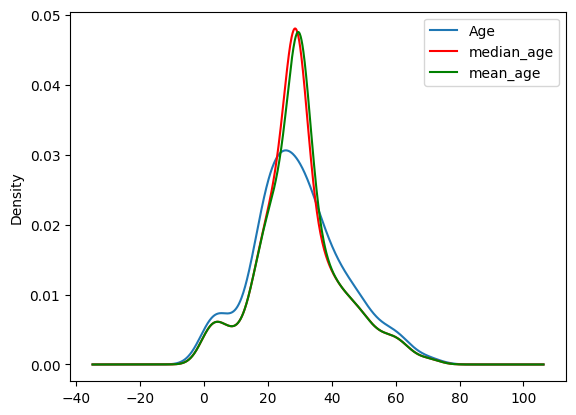

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['median_age'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['mean_age'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

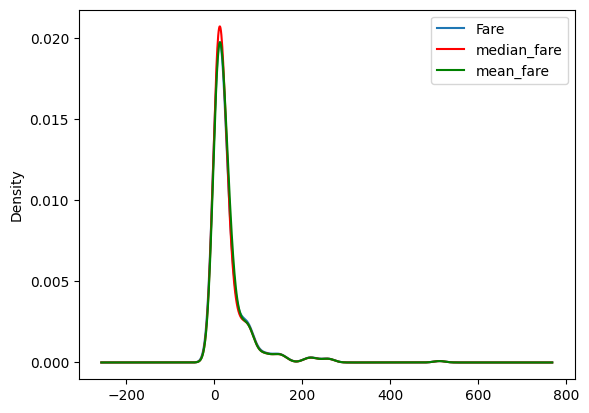

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['median_fare'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['mean_fare'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [18]:
X_train.cov()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
mean_age,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
median_age,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
mean_fare,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
median_fare,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


In [19]:
X_train.corr()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205942
mean_age,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.083461
median_age,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.086982
mean_fare,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.996607
median_fare,0.087356,1.000000,0.205942,0.083461,0.086982,0.996607,1.000000


<Axes: >

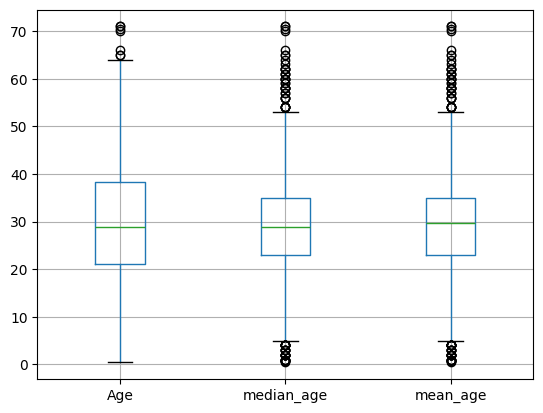

In [20]:
X_train[['Age', 'median_age', 'mean_age']].boxplot()

<Axes: >

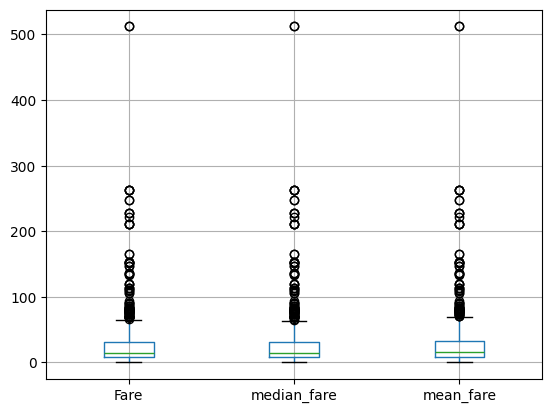

In [25]:
X_train[['Fare', 'median_fare','mean_fare']].boxplot()

Scikit Learn SimpleImputer

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [27]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [31]:
trf = ColumnTransformer([
    ('mean_age', imputer1, [0]),
    ('median_fare', imputer2, [1])
], remainder='passthrough')

In [35]:
trf.fit(X_train)
X_train_trf = trf.transform(X_train)
X_test_trf = trf.transform(X_test)


In [36]:
trf.named_transformers_['mean_age'].statistics_

array([29.78590426])

In [37]:
trf.named_transformers_['median_fare'].statistics_

array([14.4583])

In [38]:
X_train_trf

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 29.78590426, 221.7792    ,   0.        ],
       [ 29.78590426,  25.925     ,   0.        ]])